<a href="https://colab.research.google.com/github/harsh-maisheri/sql-for-data-analysis-3271025/blob/main/MCA%20Final%20Year%20ROI%20Data%20Science%20Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. Install/import required libraries
import sys, subprocess, warnings, os
warnings.filterwarnings("ignore")

try:
    import xgboost as xgb
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "xgboost"])
    import xgboost as xgb

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, silhouette_score
)
from sklearn.cluster import KMeans

sns.set_theme(style="whitegrid")
print("Libraries loaded successfully.")

In [5]:
# 2. Load the supplied dataset
file_path = "/content/AeroReach Insights.csv"

if not os.path.exists(file_path):
    from google.colab import files
    uploaded = files.upload()
    file_path = next(iter(uploaded))

df = pd.read_csv(file_path)

print("Dataset loaded successfully")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
display(df.head())


Saving AeroReach Insights.csv to AeroReach Insights.csv
Dataset loaded successfully
Rows: 11760
Columns: 17


,UserID,Taken_product,Yearly_avg_view_on_travel_page,preferred_device,total_likes_on_outstation_checkin_given,yearly_avg_Outstation_checkins,member_in_family,preferred_location_type,Yearly_avg_comment_on_travel_page,total_likes_on_outofstation_checkin_received,week_since_last_outstation_checkin,following_company_page,montly_avg_comment_on_company_page,working_flag,travelling_network_rating,Adult_flag(Age Group),Daily_Avg_mins_spend_on_traveling_page
0,1000001,Yes,307.0,iOS and Android,38570.0,1,2,Business Travel,94.0,5993,8,Yes,11,No,1,36 & Above1-36 & Above536 & Above1-36 & Above5...,8
1,1000002,No,367.0,iOS,9765.0,1,1,Business Travel,61.0,5130,1,No,23,Yes,4,36 & Above1-36 & Above56-36 & Above0,10
2,1000003,Yes,277.0,iOS and Android,48055.0,1,2,Other,92.0,2090,6,Yes,15,No,2,36 & Above1-36 & Above536 & Above1-36 & Above5...,7
3,1000004,No,247.0,iOS,48720.0,1,4,Business Travel,56.0,2909,1,Yes,11,No,3,36 & Above1-36 & Above536 & Above1-36 & Above5...,8
4,1000005,No,202.0,iOS and Android,20685.0,1,1,Medical Tourism,40.0,3468,9,No,12,No,4,36 & Above1-36 & Above56-36 & Above0,6


In [6]:
print("Shape:", df.shape)
print("\nColumns:")
for i, c in enumerate(df.columns, 1):
    print(f"{i}. {c}")

print("\nDuplicate rows:", df.duplicated().sum())
print("Unique UserID:", df["UserID"].nunique())

print("\nTarget distribution:")
target_counts = df["Taken_product"].value_counts()
display(target_counts.to_frame("Count"))
display((df["Taken_product"].value_counts(normalize=True)*100).round(2).to_frame("Percentage"))

Shape: (11760, 17)

Columns:
1. UserID
2. Taken_product
3. Yearly_avg_view_on_travel_page
4. preferred_device
5. total_likes_on_outstation_checkin_given
6. yearly_avg_Outstation_checkins
7. member_in_family
8. preferred_location_type
9. Yearly_avg_comment_on_travel_page
10. total_likes_on_outofstation_checkin_received
11. week_since_last_outstation_checkin
12. following_company_page
13. montly_avg_comment_on_company_page
14. working_flag
15. travelling_network_rating
16. Adult_flag(Age Group)
17. Daily_Avg_mins_spend_on_traveling_page

Duplicate rows: 0
Unique UserID: 11760

Target distribution:


,Count
Taken_product,
No,9864
Yes,1896


,Percentage
Taken_product,
No,83.88
Yes,16.12


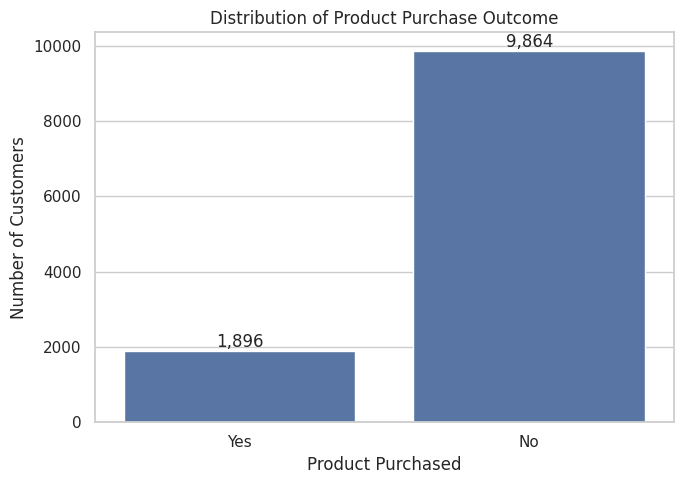

In [7]:
plt.figure(figsize=(7,5))
ax = sns.countplot(data=df, x="Taken_product")
plt.title("Distribution of Product Purchase Outcome")
plt.xlabel("Product Purchased")
plt.ylabel("Number of Customers")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}", (p.get_x()+p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
plt.tight_layout()
plt.show()

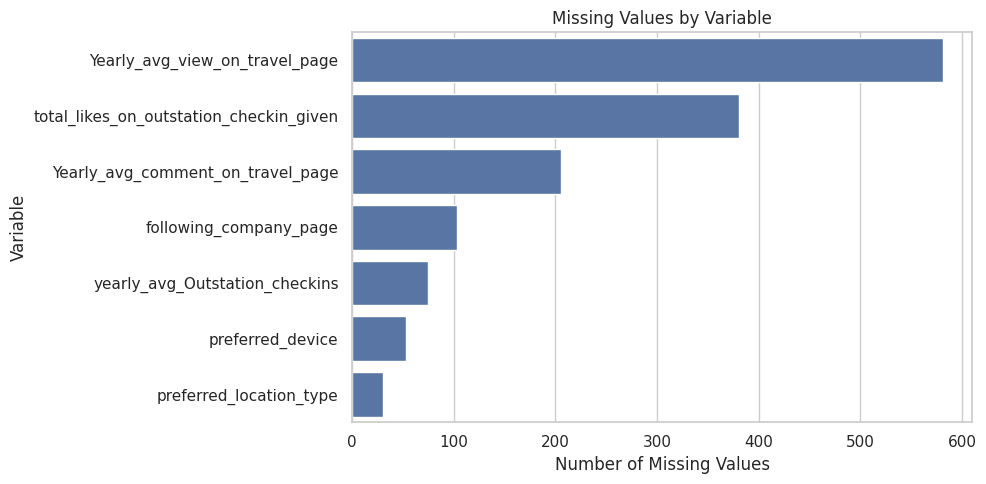

,Missing Values
Yearly_avg_view_on_travel_page,581
total_likes_on_outstation_checkin_given,381
Yearly_avg_comment_on_travel_page,206
following_company_page,103
yearly_avg_Outstation_checkins,75
preferred_device,53
preferred_location_type,31


In [8]:
missing = df.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]

plt.figure(figsize=(10,5))
if len(missing):
    sns.barplot(x=missing.values, y=missing.index)
    plt.title("Missing Values by Variable")
    plt.xlabel("Number of Missing Values")
    plt.ylabel("Variable")
else:
    plt.text(0.5, 0.5, "No missing values", ha="center", va="center")
    plt.title("Missing Values by Variable")
plt.tight_layout()
plt.show()

display(missing.to_frame("Missing Values"))


In [9]:
clean = df.copy()

# Convert text/numeric mixed columns
clean["yearly_avg_Outstation_checkins"] = pd.to_numeric(
    clean["yearly_avg_Outstation_checkins"].replace({"Three": 3}), errors="coerce"
)
clean["member_in_family"] = pd.to_numeric(
    clean["member_in_family"].replace({"Three": 3}), errors="coerce"
)

# Standardize device categories
clean["preferred_device"] = clean["preferred_device"].replace({
    "Android OS": "Android",
    "ANDROID": "Android"
})

# Standardize company-page following
clean["following_company_page"] = clean["following_company_page"].replace({
    "1": "Yes", "0": "No", 1: "Yes", 0: "No"
})

# Remove identifier and malformed age field as documented
clean = clean.drop(columns=["UserID", "Adult_flag(Age Group)"])

print("Cleaning completed.")
print("Modeling dataset shape:", clean.shape)
print("\nRemaining missing values:")
display(clean.isna().sum().sort_values(ascending=False).to_frame("Missing Values"))


Cleaning completed.
Modeling dataset shape: (11760, 15)

Remaining missing values:


,Missing Values
Yearly_avg_view_on_travel_page,581
total_likes_on_outstation_checkin_given,381
Yearly_avg_comment_on_travel_page,206
following_company_page,103
yearly_avg_Outstation_checkins,76
preferred_device,53
preferred_location_type,31
member_in_family,0
Taken_product,0
total_likes_on_outofstation_checkin_received,0


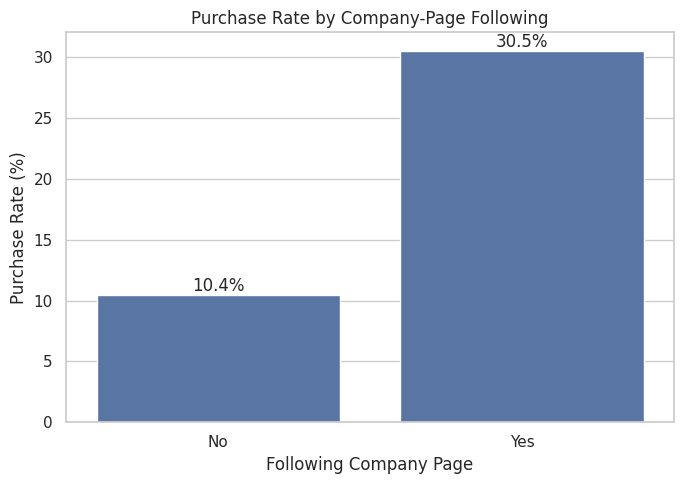

,following_company_page,Purchase Rate (%)
0,No,10.44
1,Yes,30.51
2,NaN,16.50


In [10]:
tmp = clean.copy()
tmp["purchase_flag"] = (tmp["Taken_product"] == "Yes").astype(int)
rate_follow = tmp.groupby("following_company_page", dropna=False)["purchase_flag"].mean().mul(100).reset_index()

plt.figure(figsize=(7,5))
ax = sns.barplot(data=rate_follow, x="following_company_page", y="purchase_flag")
plt.title("Purchase Rate by Company-Page Following")
plt.xlabel("Following Company Page")
plt.ylabel("Purchase Rate (%)")
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", (p.get_x()+p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
plt.tight_layout()
plt.show()

display(rate_follow.rename(columns={"purchase_flag":"Purchase Rate (%)"}).round(2))


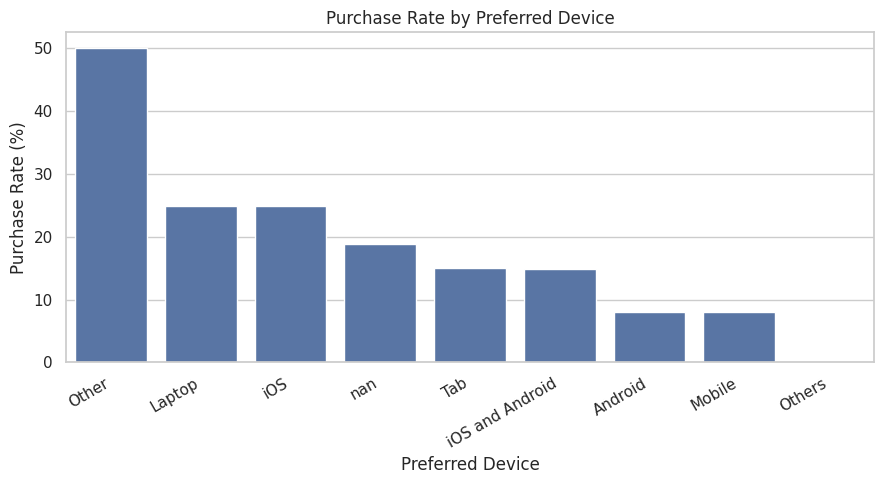

In [11]:
rate_device = tmp.groupby("preferred_device", dropna=False)["purchase_flag"].mean().mul(100).sort_values(ascending=False)

plt.figure(figsize=(9,5))
ax = sns.barplot(x=rate_device.index.astype(str), y=rate_device.values)
plt.title("Purchase Rate by Preferred Device")
plt.xlabel("Preferred Device")
plt.ylabel("Purchase Rate (%)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


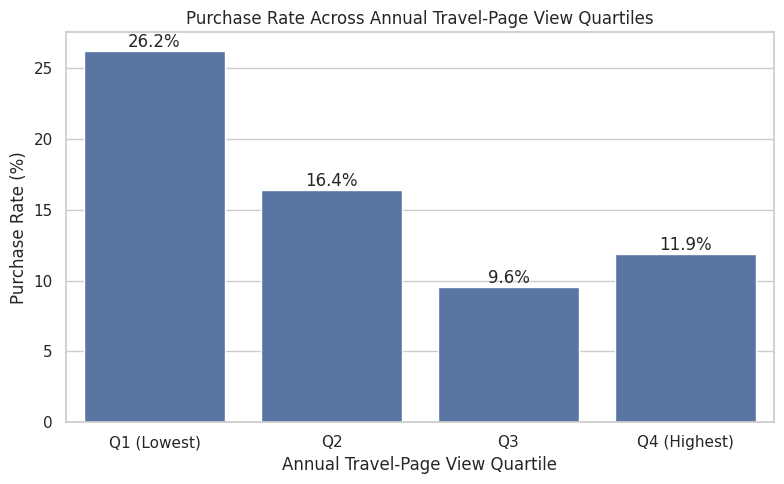

,Purchase Rate (%)
view_quartile,
Q1 (Lowest),26.24
Q2,16.38
Q3,9.57
Q4 (Highest),11.89


In [12]:
tmp["view_quartile"] = pd.qcut(
    tmp["Yearly_avg_view_on_travel_page"], 4,
    labels=["Q1 (Lowest)", "Q2", "Q3", "Q4 (Highest)"],
    duplicates="drop"
)
view_rate = tmp.groupby("view_quartile", observed=False)["purchase_flag"].mean().mul(100)

plt.figure(figsize=(8,5))
ax = sns.barplot(x=view_rate.index.astype(str), y=view_rate.values)
plt.title("Purchase Rate Across Annual Travel-Page View Quartiles")
plt.xlabel("Annual Travel-Page View Quartile")
plt.ylabel("Purchase Rate (%)")
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", (p.get_x()+p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
plt.tight_layout()
plt.show()
display(view_rate.round(2).to_frame("Purchase Rate (%)"))


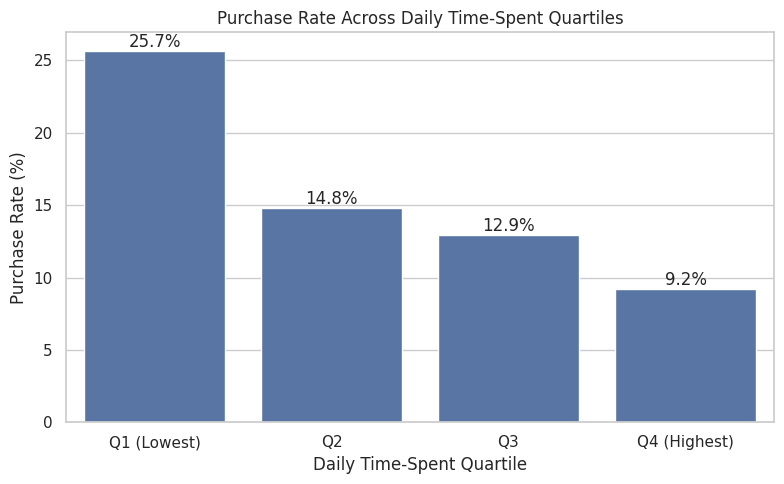

,Purchase Rate (%)
time_quartile,
Q1 (Lowest),25.65
Q2,14.83
Q3,12.94
Q4 (Highest),9.22


In [13]:
tmp["time_quartile"] = pd.qcut(
    tmp["Daily_Avg_mins_spend_on_traveling_page"], 4,
    labels=["Q1 (Lowest)", "Q2", "Q3", "Q4 (Highest)"],
    duplicates="drop"
)
time_rate = tmp.groupby("time_quartile", observed=False)["purchase_flag"].mean().mul(100)

plt.figure(figsize=(8,5))
ax = sns.barplot(x=time_rate.index.astype(str), y=time_rate.values)
plt.title("Purchase Rate Across Daily Time-Spent Quartiles")
plt.xlabel("Daily Time-Spent Quartile")
plt.ylabel("Purchase Rate (%)")
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", (p.get_x()+p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
plt.tight_layout()
plt.show()
display(time_rate.round(2).to_frame("Purchase Rate (%)"))


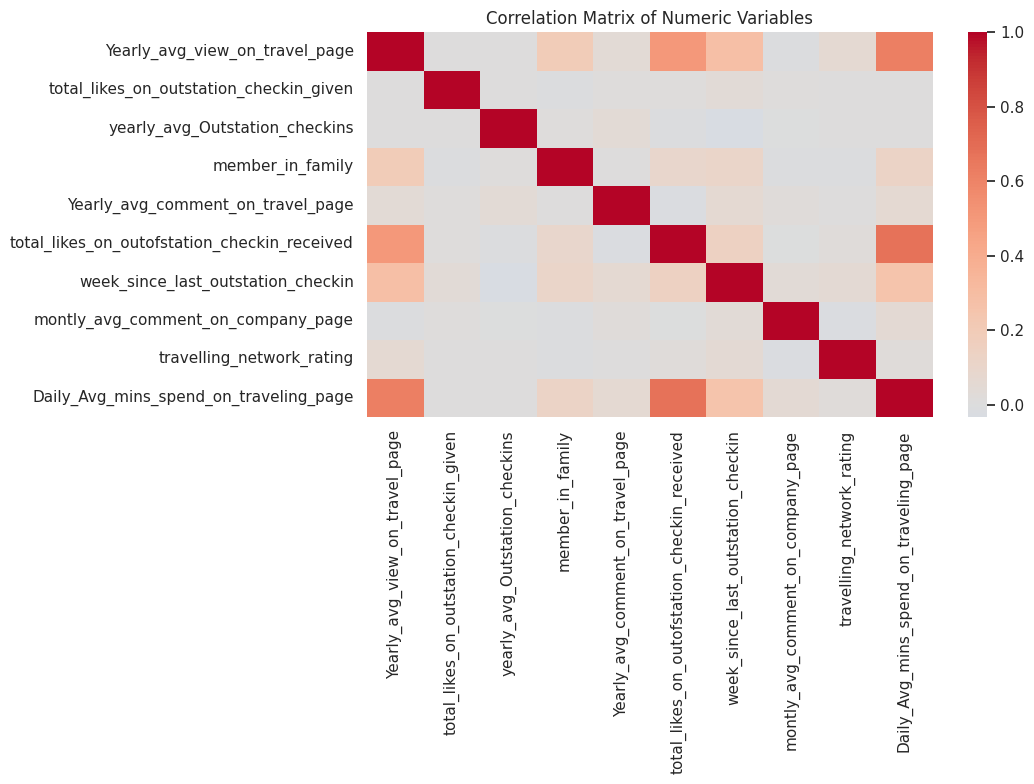

In [14]:
numeric_cols = clean.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(11,8))
sns.heatmap(clean[numeric_cols].corr(), cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Matrix of Numeric Variables")
plt.tight_layout()
plt.show()


In [15]:
X = clean.drop(columns=["Taken_product"])
y = clean["Taken_product"].map({"No": 0, "Yes": 1})

categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X.select_dtypes(include=np.number).columns.tolist()

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipe, numeric_cols),
    ("categorical", categorical_pipe, categorical_cols)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))
print("Train positive rate:", round(y_train.mean()*100, 2), "%")
print("Test positive rate:", round(y_test.mean()*100, 2), "%")


Training rows: 9408
Test rows: 2352
Train positive rate: 16.12 %
Test positive rate: 16.11 %


In [18]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=500, random_state=42, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": xgb.XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )
}

In [19]:
pipelines = {
    name: Pipeline([("preprocess", preprocessor), ("model", model)])
    for name, model in models.items()
}

In [20]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_results = []
for name, pipe in pipelines.items():
    scores = cross_validate(
        pipe, X_train, y_train, cv=cv, scoring=scoring,
        n_jobs=-1, return_train_score=False
    )
    cv_results.append({
        "Model": name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1": scores["test_f1"].mean(),
        "ROC-AUC": scores["test_roc_auc"].mean()
    })

cv_df = pd.DataFrame(cv_results).sort_values("ROC-AUC", ascending=False)
print("Five-Fold Cross-Validation Results")
display(cv_df.style.format({
    "Accuracy":"{:.2%}", "Precision":"{:.2%}", "Recall":"{:.2%}",
    "F1":"{:.2%}", "ROC-AUC":"{:.2%}"
}))


Five-Fold Cross-Validation Results


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
1,Random Forest,96.87%,98.90%,81.54%,89.37%,99.62%
3,XGBoost,96.92%,98.27%,82.33%,89.60%,99.37%
2,Gradient Boosting,88.87%,87.58%,36.12%,51.12%,89.47%
0,Logistic Regression,85.34%,74.64%,13.97%,23.51%,76.58%


<Figure size 1200x600 with 0 Axes>

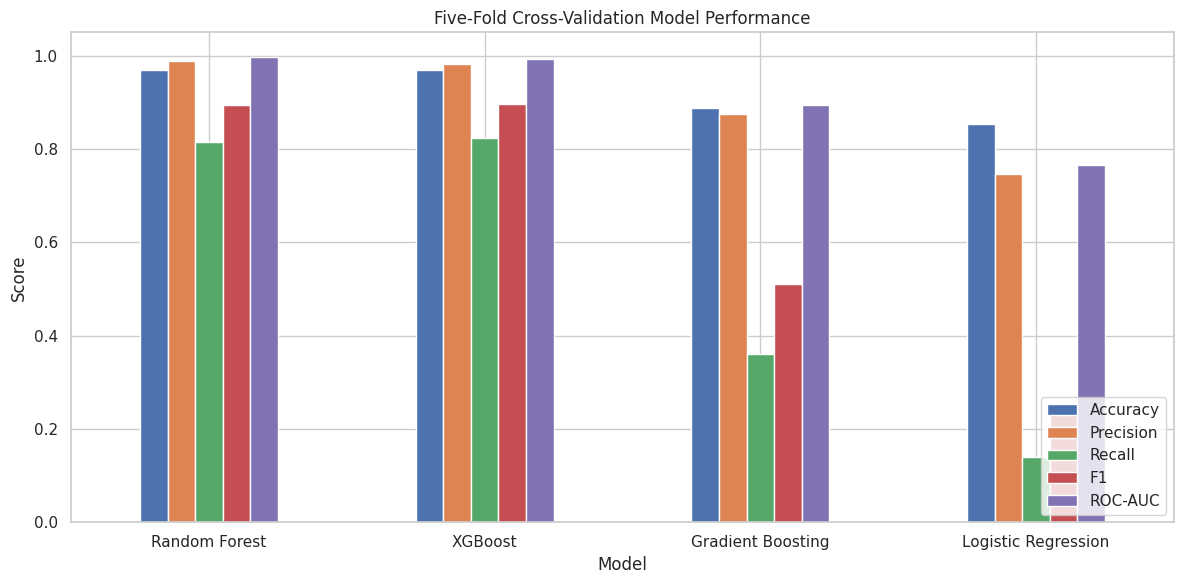

In [21]:
plot_df = cv_df.set_index("Model")[["Accuracy","Precision","Recall","F1","ROC-AUC"]]

plt.figure(figsize=(12,6))
plot_df.plot(kind="bar", figsize=(12,6))
plt.title("Five-Fold Cross-Validation Model Performance")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.ylim(0,1.05)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


In [22]:
holdout_rows = []
fitted_models = {}

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    fitted_models[name] = pipe

    pred = pipe.predict(X_test)
    prob = pipe.predict_proba(X_test)[:,1]

    holdout_rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, prob)
    })

holdout_df = pd.DataFrame(holdout_rows).sort_values("ROC-AUC", ascending=False)

print("Holdout Test-Set Results")
display(holdout_df.style.format({
    "Accuracy":"{:.2%}", "Precision":"{:.2%}", "Recall":"{:.2%}",
    "F1":"{:.2%}", "ROC-AUC":"{:.2%}"
}))


Holdout Test-Set Results


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
1,Random Forest,97.62%,100.00%,85.22%,92.02%,99.93%
3,XGBoost,97.15%,98.15%,83.91%,90.47%,99.59%
2,Gradient Boosting,88.44%,85.43%,34.04%,48.68%,88.61%
0,Logistic Regression,85.12%,66.67%,15.30%,24.89%,74.20%


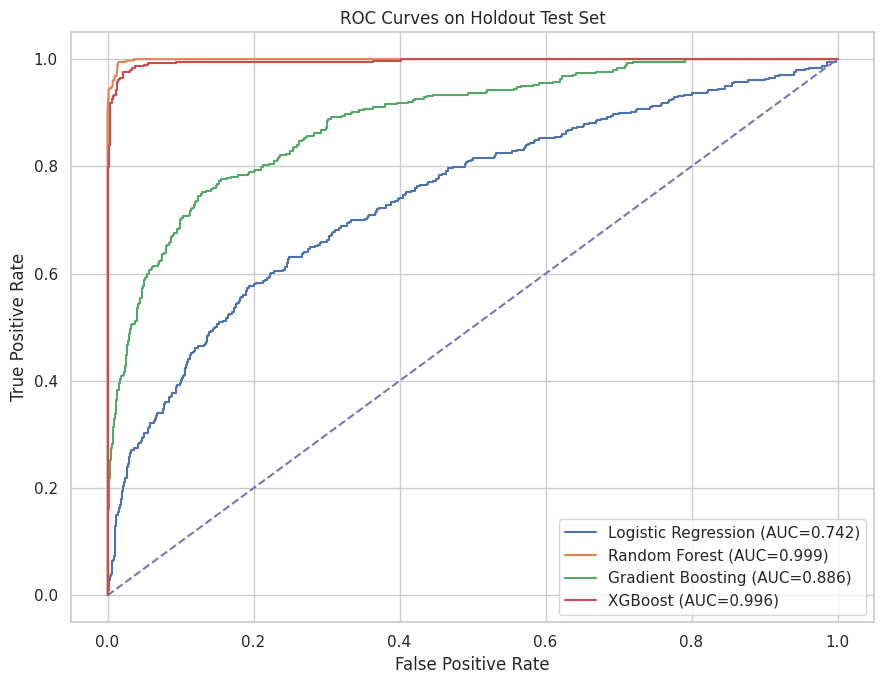

In [23]:
plt.figure(figsize=(9,7))

for name, pipe in fitted_models.items():
    prob = pipe.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0,1], [0,1], linestyle="--")
plt.title("ROC Curves on Holdout Test Set")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()


In [24]:
rf_pipe = fitted_models["Random Forest"]
rf_pred = rf_pipe.predict(X_test)
rf_prob = rf_pipe.predict_proba(X_test)[:,1]
rf_cm = confusion_matrix(y_test, rf_pred)

print("Random Forest Holdout Metrics")
print("Accuracy :", f"{accuracy_score(y_test, rf_pred):.2%}")
print("Precision:", f"{precision_score(y_test, rf_pred, zero_division=0):.2%}")
print("Recall   :", f"{recall_score(y_test, rf_pred, zero_division=0):.2%}")
print("F1-score :", f"{f1_score(y_test, rf_pred, zero_division=0):.2%}")
print("ROC-AUC  :", f"{roc_auc_score(y_test, rf_prob):.2%}")
print("\nConfusion Matrix:")
print(rf_cm)


Random Forest Holdout Metrics
Accuracy : 97.62%
Precision: 100.00%
Recall   : 85.22%
F1-score : 92.02%
ROC-AUC  : 99.93%

Confusion Matrix:
[[1973    0]
 [  56  323]]


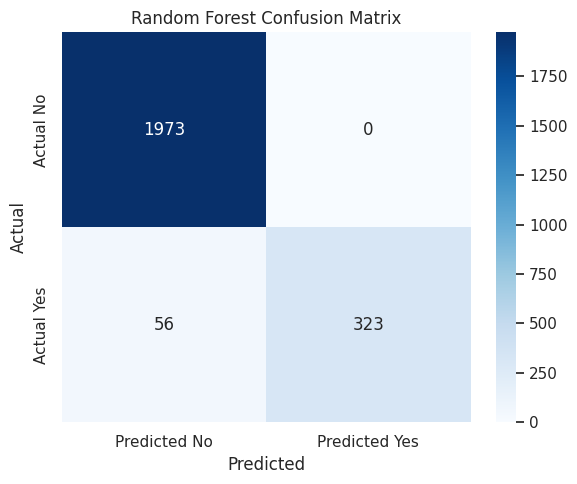

In [25]:
plt.figure(figsize=(6,5))
sns.heatmap(
    rf_cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Predicted No", "Predicted Yes"],
    yticklabels=["Actual No", "Actual Yes"]
)
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


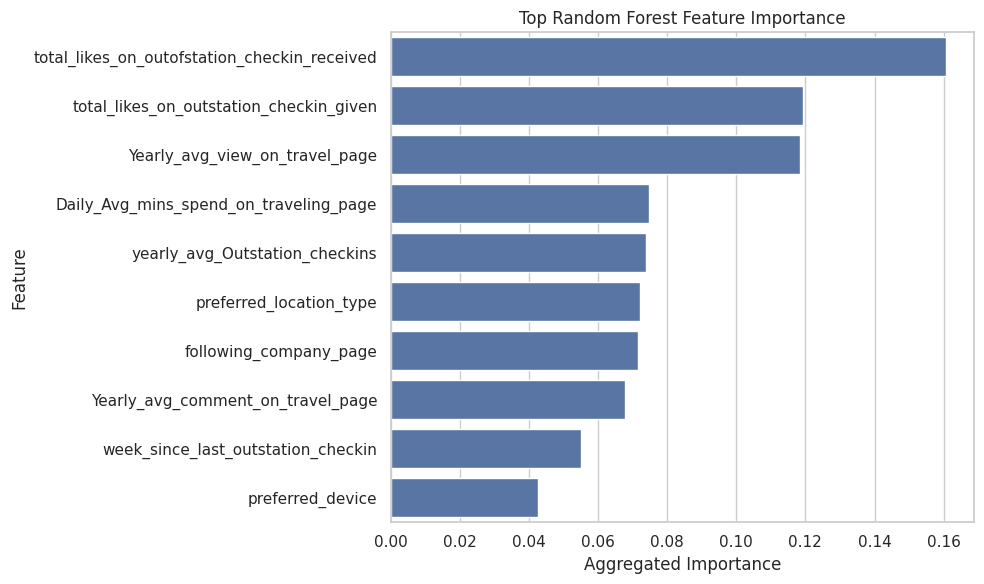

,Feature,Importance
8,total_likes_on_outofstation_checkin_received,0.1607
9,total_likes_on_outstation_checkin_given,0.1192
2,Yearly_avg_view_on_travel_page,0.1184
0,Daily_Avg_mins_spend_on_traveling_page,0.0748
13,yearly_avg_Outstation_checkins,0.0740
7,preferred_location_type,0.0720
3,following_company_page,0.0714
1,Yearly_avg_comment_on_travel_page,0.0679
11,week_since_last_outstation_checkin,0.0552
6,preferred_device,0.0427


In [26]:
pre_fitted = rf_pipe.named_steps["preprocess"]
rf_model = rf_pipe.named_steps["model"]

feature_names = pre_fitted.get_feature_names_out()
importances = rf_model.feature_importances_

importance_df = pd.DataFrame({
    "Transformed Feature": feature_names,
    "Importance": importances
})

def original_feature(transformed_name):
    name = transformed_name.split("__", 1)[-1]
    for c in categorical_cols:
        if name.startswith(c + "_"):
            return c
    return name

importance_df["Feature"] = importance_df["Transformed Feature"].apply(original_feature)
agg_importance = (
    importance_df.groupby("Feature", as_index=False)["Importance"]
    .sum()
    .sort_values("Importance", ascending=False)
)

top10 = agg_importance.head(10)

plt.figure(figsize=(10,6))
sns.barplot(data=top10, x="Importance", y="Feature")
plt.title("Top Random Forest Feature Importance")
plt.xlabel("Aggregated Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

display(top10.round(4))


In [27]:
engagement_cols = [
    "Yearly_avg_view_on_travel_page",
    "total_likes_on_outstation_checkin_given",
    "yearly_avg_Outstation_checkins",
    "Yearly_avg_comment_on_travel_page",
    "total_likes_on_outofstation_checkin_received",
    "week_since_last_outstation_checkin",
    "montly_avg_comment_on_company_page",
    "Daily_Avg_mins_spend_on_traveling_page"
]

cluster_data = clean[engagement_cols].copy()
cluster_data = SimpleImputer(strategy="median").fit_transform(cluster_data)
cluster_scaled = StandardScaler().fit_transform(cluster_data)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=20)
clusters = kmeans.fit_predict(cluster_scaled)

cluster_df = clean.copy()
cluster_df["Cluster"] = clusters
cluster_summary = (
    cluster_df.groupby("Cluster")
    .agg(Customers=("Taken_product","size"),
         Purchase_Rate=("Taken_product", lambda s: (s=="Yes").mean()*100))
    .sort_values("Purchase_Rate", ascending=False)
)

sil = silhouette_score(cluster_scaled, clusters)

print("K-Means: 4 clusters")
print("Silhouette Score:", round(sil, 3))
display(cluster_summary.round(2))


K-Means: 4 clusters
Silhouette Score: 0.188


,Customers,Purchase_Rate
Cluster,,
1,6212,17.95
0,3508,17.53
2,191,17.28
3,1849,7.19


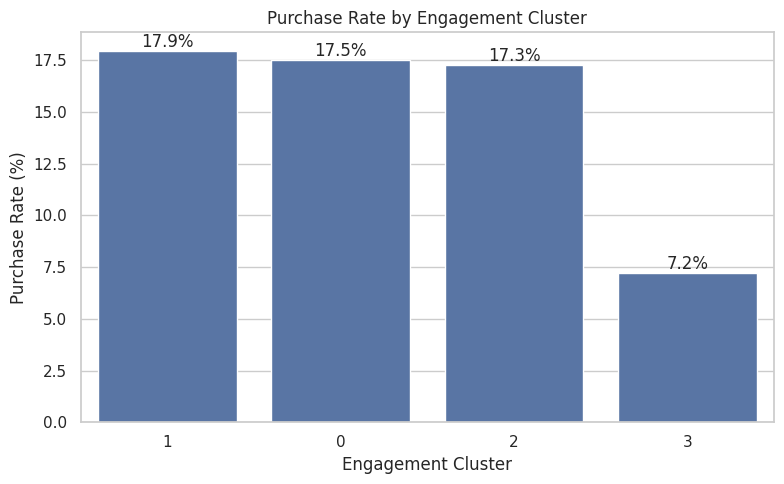

In [28]:
plt.figure(figsize=(8,5))
ax = sns.barplot(
    x=cluster_summary.index.astype(str),
    y=cluster_summary["Purchase_Rate"].values
)
plt.title("Purchase Rate by Engagement Cluster")
plt.xlabel("Engagement Cluster")
plt.ylabel("Purchase Rate (%)")
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", (p.get_x()+p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
plt.tight_layout()
plt.show()

In [30]:
report_cv = pd.DataFrame({
    "Model": ["Logistic Regression","Random Forest","Gradient Boosting","XGBoost"],
    "Accuracy": [0.7093,0.9795,0.8777,0.9065],
    "Precision": [0.3182,0.9866,0.8709,0.9295],
    "Recall": [0.7010,0.8850,0.2838,0.4552],
    "F1": [0.4375,0.9329,0.4277,0.6102],
    "ROC-AUC": [0.7704,0.9965,0.8649,0.9356]
})

report_holdout = pd.DataFrame({
    "Metric": ["Accuracy","Precision","Recall","F1-score","ROC-AUC"],
    "Report Value": [0.9753,0.9938,0.8522,0.9176,0.9980]
})

print("Published CV benchmark in supplied report:")
display(report_cv.style.format({
    "Accuracy":"{:.2%}","Precision":"{:.2%}","Recall":"{:.2%}",
    "F1":"{:.2%}","ROC-AUC":"{:.2%}"
}))

print("Published Random Forest holdout benchmark in supplied report:")
display(report_holdout.style.format({"Report Value":"{:.2%}"}))

print("\nNOTE: Do not overwrite calculated metrics with these benchmark values.")

os.makedirs("/content/AeroReach_outputs", exist_ok=True)

cv_df.to_csv("/content/AeroReach_outputs/cross_validation_results.csv", index=False)
holdout_df.to_csv("/content/AeroReach_outputs/holdout_results.csv", index=False)
agg_importance.to_csv("/content/AeroReach_outputs/random_forest_feature_importance.csv", index=False)
cluster_summary.to_csv("/content/AeroReach_outputs/kmeans_cluster_summary.csv")

print("Project completed.")
print("Result files saved in: /content/AeroReach_outputs/")

Published CV benchmark in supplied report:


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,70.93%,31.82%,70.10%,43.75%,77.04%
1,Random Forest,97.95%,98.66%,88.50%,93.29%,99.65%
2,Gradient Boosting,87.77%,87.09%,28.38%,42.77%,86.49%
3,XGBoost,90.65%,92.95%,45.52%,61.02%,93.56%


Published Random Forest holdout benchmark in supplied report:


,Metric,Report Value
0,Accuracy,97.53%
1,Precision,99.38%
2,Recall,85.22%
3,F1-score,91.76%
4,ROC-AUC,99.80%



NOTE: Do not overwrite calculated metrics with these benchmark values.
Project completed.
Result files saved in: /content/AeroReach_outputs/
